# Loading the Reuters Dataset

In [2]:
from tensorflow.keras.datasets import reuters
(train_data,train_labels),(test_data,test_labels)=reuters.load_data(num_words=10000)

In [3]:
# reuters.get_word_index().get(,"Not Present")

In [4]:
len(train_data)

8982

In [5]:
len(test_data)

2246

In [6]:
train_data.shape  #There is 8982 lists of news present there

(8982,)

In [7]:
len(train_data[10]) ,len(train_data[0])

(31, 87)

In [8]:
#Lets we decode our data
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]]) 

In [9]:
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [10]:
# Lets we can encode our training Data
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      for j in sequence:
        results[i, j] = 1.
    return results


In [11]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [12]:
x_train.shape

(8982, 10000)

In [32]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [41]:
# def to_one_hot(labels, dimension=46):
#     results = np.zeros((len(labels), dimension))
#     for i, label in enumerate(labels):
#         results[i, label] = 1. 
#     return results

In [42]:
# y_train = to_one_hot(train_labels)   
# y_test = to_one_hot(test_labels)

In [43]:
#This is the another built in way to encode lebels in keras
# from tensorflow.keras.utils import to_categorical
# y_train = to_categorical(train_labels)
# y_test = to_categorical(test_labels)

In [34]:
y_train

array([ 3.,  4.,  3., ..., 25.,  3., 25.], shape=(8982,), dtype=float32)

In [35]:
y_test

array([ 3., 10.,  1., ...,  3.,  3., 24.], shape=(2246,), dtype=float32)

## Model Defining

In [19]:
from tensorflow import keras
from keras import layers
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

In [20]:
#Compiling Our Model
model.compile(optimizer="rmsprop",
      loss="sparse_categorical_crossentropy",  #we do there categorical_crossentropy ,because we encode our labels above 
      metrics=["accuracy"])

In [21]:
# We seperating our training and validation data there
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

### Training Our Model

In [22]:
history = model.fit(partial_x_train,
partial_y_train,
epochs=20,
batch_size=512,
validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.4896 - loss: 2.7203 - val_accuracy: 0.5590 - val_loss: 1.8557
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6428 - loss: 1.5969 - val_accuracy: 0.6680 - val_loss: 1.4562
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7241 - loss: 1.2606 - val_accuracy: 0.7180 - val_loss: 1.2558
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7730 - loss: 1.0439 - val_accuracy: 0.7550 - val_loss: 1.1335
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8106 - loss: 0.8779 - val_accuracy: 0.7820 - val_loss: 1.0713
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8448 - loss: 0.7372 - val_accuracy: 0.7880 - val_loss: 1.0029
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8673 - loss: 0.6258 - val_accuracy: 0.8030 - val_loss: 0.9410
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8872 - loss: 0.5326 - val_accuracy: 0.8090 - v

In [23]:
history_dict=history.history

In [24]:
import pandas as pd
pd.DataFrame(history_dict)

,accuracy,loss,val_accuracy,val_loss
0,0.489602,2.720318,0.559,1.855724
1,0.642821,1.596921,0.668,1.456205
2,0.724129,1.260595,0.718,1.255828
3,0.772989,1.043872,0.755,1.133511
4,0.810574,0.877928,0.782,1.071258
5,0.844776,0.737241,0.788,1.002913
6,0.867326,0.625752,0.803,0.941044
7,0.887246,0.532596,0.809,0.909177
8,0.905036,0.448972,0.813,0.899514
9,0.917690,0.388191,0.821,0.886779


## Training and Validation Loss

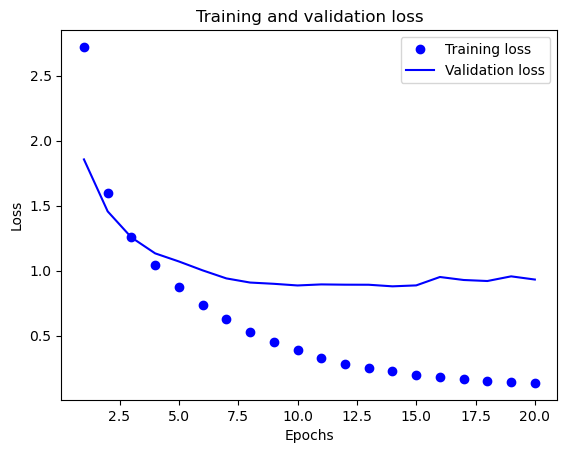

In [25]:
import matplotlib.pyplot as plt
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

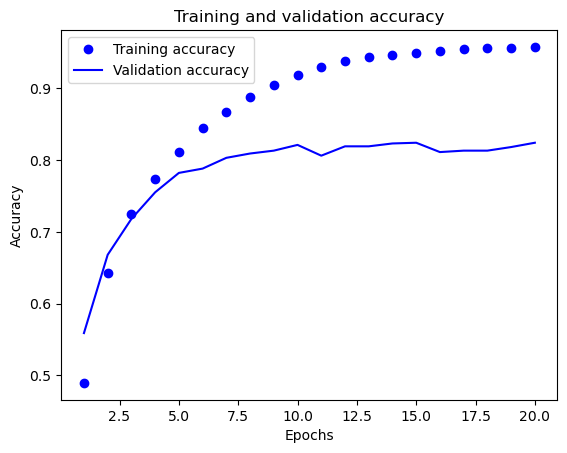

In [26]:
plt.clf()  #It clears the figure
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [36]:
#Retraining Our Model From Scratch
from tensorflow import keras
from keras import layers
model=keras.Sequential([
    layers.Dense(64,activation="relu"),
    layers.Dense(64,activation="relu"),
    layers.Dense(46,activation="softmax")
])

In [37]:
#compiling Our Model
model.compile(optimizer="rmsprop",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [38]:
model.fit(x_train,
  y_train,
  epochs=9,
  batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.4709 - loss: 2.7484
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6642 - loss: 1.5432
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7455 - loss: 1.1838
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7938 - loss: 0.9715
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8277 - loss: 0.8052
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8517 - loss: 0.6757
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8798 - loss: 0.5619
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8969 - loss: 0.4736
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9119 - loss: 0.4000
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7943 - loss: 0.9166


In [39]:
results

[0.9165618419647217, 0.7943009734153748]

In [40]:
#Original dictionary
reuters_label_dict = {'copper': 6, 'livestock': 28, 'gold': 25, 'money-fx': 19, 'ipi': 30, 'trade': 11, 'cocoa': 0, 'iron-steel': 31, 'reserves': 12, 'tin': 26, 'zinc': 37, 'jobs': 34, 'ship': 13, 'cotton': 14, 'alum': 23, 'strategic-metal': 27, 'lead': 45, 'housing': 7, 'meal-feed': 22, 'gnp': 21, 'sugar': 10, 'rubber': 32, 'dlr': 40, 'veg-oil': 2, 'interest': 20, 'crude': 16, 'coffee': 9, 'wheat': 5, 'carcass': 15, 'lei': 35, 'gas': 41, 'nat-gas': 17, 'oilseed': 24, 'orange': 38, 'heat': 33, 'wpi': 43, 'silver': 42, 'cpi': 18, 'earn': 3, 'bop': 36, 'money-supply': 8, 'hog': 44, 'acq': 4, 'pet-chem': 39, 'grain': 1, 'retail': 29}

#reverse the dictionary
reuters_label_reversed = {v:k for k, v in reuters_label_dict.items()}

In [41]:
predictions=model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [42]:
predictions[0].shape

(46,)

In [44]:
y_pred=[]
for p in predictions:
    y_pred.append(reuters_label_reversed.get(np.argmax(p)))
y_pred

['earn',
 'sugar',
 'grain',
 'acq',
 'ship',
 'earn',
 'earn',
 'earn',
 'earn',
 'earn',
 'grain',
 'acq',
 'grain',
 'earn',
 'grain',
 'trade',
 'earn',
 'earn',
 'money-fx',
 'earn',
 'money-supply',
 'earn',
 'earn',
 'earn',
 'coffee',
 'earn',
 'acq',
 'copper',
 'sugar',
 'earn',
 'earn',
 'sugar',
 'crude',
 'earn',
 'money-fx',
 'acq',
 'interest',
 'grain',
 'acq',
 'earn',
 'grain',
 'gnp',
 'earn',
 'reserves',
 'acq',
 'acq',
 'earn',
 'acq',
 'earn',
 'trade',
 'interest',
 'earn',
 'earn',
 'earn',
 'earn',
 'money-fx',
 'veg-oil',
 'acq',
 'interest',
 'money-fx',
 'acq',
 'earn',
 'acq',
 'acq',
 'acq',
 'earn',
 'earn',
 'grain',
 'earn',
 'acq',
 'earn',
 'acq',
 'earn',
 'money-fx',
 'wpi',
 'oilseed',
 'grain',
 'earn',
 'interest',
 'acq',
 'earn',
 'earn',
 'earn',
 'trade',
 'money-fx',
 'interest',
 'earn',
 'money-fx',
 'acq',
 'earn',
 'earn',
 'acq',
 'earn',
 'interest',
 'earn',
 'trade',
 'trade',
 'earn',
 'acq',
 'veg-oil',
 'gas',
 'earn',
 'interest